In [ ]:
# ==========================================
# 1. SETUP & COLAB CONFIGURATION
# ==========================================
import torch
import numpy as np
import os
import sys
from torchvision.utils import save_image, make_grid
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")

CUDA Available: True
CUDA Version: 12.6


Get project folder local or colab

In [ ]:
# Mount Google Drive
# --- 1. Detect Environment ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 2. Set Paths Based on Environment ---
if IN_COLAB:
    print("✅ Detected Environment: Google Colab")
    # Mount Drive
    if not os.path.isdir('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')

    # Define Colab Path (Linux Style)
    PROJECT_DIR = '/content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data'

else:
    print("✅ Detected Environment: Local (VS Code)")

    # Define Local Path (Windows Style)
    # Option A: If you use Google Drive for Desktop (G: Drive)
    # Note: "Shareddrives" in Colab usually maps to "Shared drives" (with space) in Windows
    PROJECT_DIR = r'H:\Shared drives\Generative_Models\colab_code\Sample_Data'

    # Option B: If you opened the folder directly in VS Code, just use current dir
    # PROJECT_DIR = os.getcwd()

# --- 3. Add to System Path ---
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)
    print(f"Added to sys.path: {PROJECT_DIR}")

# if not os.path.isdir('/content/drive'):
#     print("Mounting Google Drive...")
#     drive.mount('/content/drive')

# # 2. Define the path to your project folder
# # Replace this path with the actual location of your network.py file
# PROJECT_DIR  = '/content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data' #for eldar
# # 3. Add the folder to the system path
# if PROJECT_DIR not in sys.path:
#     sys.path.append(PROJECT_DIR)
# # Output folder for the results

✅ Detected Environment: Google Colab
Mounting Google Drive...
Mounted at /content/drive
Added to sys.path: /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data


Add Paths and create output folder

In [ ]:
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'Sample_output','base_model_taskA_then_B')
os.makedirs(OUTPUT_DIR, exist_ok=True)

#Load Model

Paramters and paths

In [ ]:
# Import your custom modules
try:
    from network import DDPM, ContextUnet
    print("✅ Successfully imported network.py")
except ImportError as e:
    print(f"❌ Error importing network.py: {e}")
    print("Please double check the PROJECT_DIR path above.")

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "Models_Path/base_model/phase2_taskB_digits_6to9_from_taskA/model_taskA_then_B.pth"
)
print(MODEL_PATH)
# Generation Config
TARGET_LABEL = 3           # The digit to generate
NUM_SAMPLES = 1000         # Total number of images
BATCH_SIZE = 100           # Images per batch (keep < 200 for Colab GPU memory)
GUIDE_W = 2.0              # Guidance scale (2.0 is standard for clearer digits)

✅ Successfully imported network.py
/content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Models_Path/base_model/phase2_taskB_digits_6to9_from_taskA/model_taskA_then_B.pth


load model

In [ ]:
# Model Hyperparameters (Must match training!)
N_FEAT = 128
N_CLASSES = 10
N_T = 400
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Running on {DEVICE}")
# ==========================================
# 3. LOAD MODEL
# ==========================================
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Model file not found at: {MODEL_PATH}\nPlease update the MODEL_PATH variable.")

ddpm = DDPM(
    nn_model=ContextUnet(in_channels=1, n_feat=N_FEAT, n_classes=N_CLASSES),
    betas=(1e-4, 0.02),
    n_T=N_T,
    device=DEVICE,
    drop_prob=0.1
).to(DEVICE)

# Load weights
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
if "model_state_dict" in state_dict:
    state_dict = state_dict["model_state_dict"]
ddpm.load_state_dict(state_dict)
ddpm.eval()
print("✅ Model loaded successfully!")

🚀 Running on cuda
✅ Model loaded successfully!


In [ ]:
# ==========================================
# 4. GENERATION LOOP
# ==========================================
for TARGET_LABEL in range(0,10):
  print(f"🎨 Generating {NUM_SAMPLES} samples of digit '{TARGET_LABEL}'...")

  all_samples = []
  num_batches = int(np.ceil(NUM_SAMPLES / BATCH_SIZE))

  with torch.no_grad():
      for b in tqdm(range(num_batches), desc="Sampling Batches"):
          # Calculate batch size (handle last batch remainder)
          current_batch_size = min(BATCH_SIZE, NUM_SAMPLES - len(all_samples))
          if current_batch_size <= 0:
              break

          # Create the label tensor filled with '9'
          c = torch.full((current_batch_size,), TARGET_LABEL, device=DEVICE, dtype=torch.long)

          # Generate!
          # using .prediction() allows specific labels 'c'
          x_gen, _ = ddpm.prediction(
              n_sample=current_batch_size,
              size=(1, 28, 28),
              c=c,
              device=DEVICE,
              guide_w=GUIDE_W
          )

          # Move to CPU to save GPU memory
          all_samples.append(x_gen.cpu())

  # Combine all batches
  all_samples = torch.cat(all_samples, dim=0)
  all_samples = all_samples[:NUM_SAMPLES] # Trim to exact count

  print(f"\n✨ Generated tensor shape: {all_samples.shape}")
  # ==========================================
  # 5. SAVE RESULTS TO DRIVE
  # ==========================================
  save_prefix = f"digit_{TARGET_LABEL}"

  # A. Save as .npz (Standard for FID/Metrics)
  npz_path = os.path.join(OUTPUT_DIR, f"{save_prefix}_{NUM_SAMPLES}.npz")
  np.savez_compressed(npz_path, samples=all_samples.numpy())
  print(f"💾 Saved raw samples to: {npz_path}")

  # B. Save a visual grid (First 100 images)
  grid_samples = all_samples[:100]
  # Invert colors (-1..1 -> 0..1) for MNIST visualization
  grid_img = make_grid(grid_samples * -1 + 1, nrow=10)
  img_path = os.path.join(OUTPUT_DIR, f"{save_prefix}_grid.png")
  save_image(grid_img, img_path)
  print(f"🖼️ Saved visual grid to: {img_path}")

🎨 Generating 1000 samples of digit '0'...


Sampling Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Sampling Batches:  10%|█         | 1/10 [00:51<07:44, 51.66s/it]

Sampling Batches:  20%|██        | 2/10 [01:41<06:45, 50.70s/it]

Sampling Batches:  30%|███       | 3/10 [02:32<05:56, 50.92s/it]

...

Sampling Batches:  70%|███████   | 7/10 [05:55<02:32, 50.84s/it]

Sampling Batches:  80%|████████  | 8/10 [06:46<01:41, 50.88s/it]

Sampling Batches:  90%|█████████ | 9/10 [07:37<00:50, 50.89s/it]

Sampling Batches: 100%|██████████| 10/10 [08:28<00:00, 50.84s/it]


✨ Generated tensor shape: torch.Size([1000, 1, 28, 28])
💾 Saved raw samples to: /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/base_model_taskA_then_B/digit_9_1000.npz
🖼️ Saved visual grid to: /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/base_model_taskA_then_B/digit_9_grid.png


In [ ]:
# ==========================================
# 5. SAVE RESULTS TO DRIVE
# ==========================================
# save_prefix = f"digit_{TARGET_LABEL}"

# # A. Save as .npz (Standard for FID/Metrics)
# npz_path = os.path.join(OUTPUT_DIR, f"{save_prefix}_{NUM_SAMPLES}.npz")
# np.savez_compressed(npz_path, samples=all_samples.numpy())
# print(f"💾 Saved raw samples to: {npz_path}")

# # B. Save a visual grid (First 100 images)
# grid_samples = all_samples[:100]
# # Invert colors (-1..1 -> 0..1) for MNIST visualization
# grid_img = make_grid(grid_samples * -1 + 1, nrow=10)
# img_path = os.path.join(OUTPUT_DIR, f"{save_prefix}_grid.png")
# save_image(grid_img, img_path)
# print(f"🖼️ Saved visual grid to: {img_path}")

# # C. Show image inline
# plt.figure(figsize=(10, 10))
# plt.imshow(grid_img.permute(1, 2, 0).numpy())
# plt.axis("off")
# plt.title(f"Generated Samples: Digit {TARGET_LABEL}")
# plt.show()

# Evaluate models

In [ ]:
# Load label
Models_name = ["NL_task_A_to_B"]
base_Folder = "Sample_output"
print(Models_name[0])
digit = 9 ;
npz_file = np.load(os.path.join(PROJECT_DIR,base_Folder,Models_name[0],f'digit_{digit}_1000.npz'))

NL_task_A_to_B


In [ ]:
images = npz_file["samples"]
plt.imshow(images[201,0])
plt.show()
print( np.min(images[201,0]))
print(np.max(images[201,0]))

NL model forgetting

In [ ]:
!pip install torchmetrics
!pip install torch-fidelity
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.7 MB/s eta 0:00:00


In [ ]:
import torchmetrics
from torchmetrics.image.fid import FrechetInceptionDistance
import torch_fidelity
import torch

from eval_ver_05 import evaluate, A_DIGITS, B_DIGITS
import numpy as np
Models_name = 'base_model_taskA_then_B'
Models_name_old = 'base_model_taskA'
load_labels = os.path.join(PROJECT_DIR,'Sample_output',Models_name)
load_labels_taskA = os.path.join(PROJECT_DIR,'Sample_output',Models_name_old)
res1 = evaluate(load_labels,load_labels_taskA)


Saved: pretrained_mnist/mnist-classifier.tar.gz
Extracting: pretrained_mnist/mnist-classifier.tar.gz
Loading .npz files from /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/base_model_taskA_then_B...
Successfully loaded 10000 images total.


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.21MB/s]


Loading previous task samples from: /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/base_model_taskA
Loading .npz files from /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/base_model_taskA...
Successfully loaded 10000 images total.


In [ ]:

import pandas as pd
import os

# 1. Create a dictionary with your column names as Keys
# The [ ] brackets around the values are crucial—they tell Pandas "this is a list of rows"
data = {
    "Accuracy A": [res1["accuracy"]["A"]],
    "Accuracy B": [res1["accuracy"]["B"]],
    "Accuracy AB": [res1["accuracy"]["AB"]],
    "FID Forgetting A":[res1["fid_forgetting_A"]],
    "ACC Forgetting A":[res1["acc_forgetting_A"]],
    "FID A prev":[res1["fid_A_prev"]],
    "Acc A prev":[res1["acc_A_prev"]],
    "FID A": [res1["FID"]["A"]],
    "FID B": [res1["FID"]["B"]],
    "FID AB avg": [res1["AFID"]]
}

# 2. Convert to a DataFrame
df = pd.DataFrame(data)
df = pd.DataFrame(data).T.reset_index()
# 3. Rename the columns to make them readable
df.columns = ["Metric", "Value"]
# 4. ROUND to 3 decimal places
df["Value"] = df["Value"].round(3)
# 5. Define path and Save
csv_path = os.path.join(load_labels, 'results_V5.csv')

# index=False prevents pandas from adding that annoying "0" column at the start
df.to_csv(csv_path, index=False)

print(f"Saved to CSV: {csv_path}")

Saved to CSV: /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/base_model_taskA_then_B/results_V5.csv


In [ ]:
import pandas as pd
print("Accuracy:", res1["accuracy"])
print("Forgetting A->B:", res1["forgetting_accuracy_A_to_B"])
print("FID:", res1["FID"])
# Define the file path
file_path = os.path.join(load_labels, 'results.txt')

with open(file_path, 'w') as f:
    # Use f.write() instead of print()
    # Note: You must add '\n' for new lines manually
    f.write(f"Accuracy: {res1['accuracy']}\n")
    f.write(f"Forgetting A->B: {res1['forgetting_accuracy_A_to_B']}\n")
    f.write(f"FID: {res1['FID']}\n")

print(f"Saved results to: {file_path}")

Accuracy: {'A': 0.8993333333333333, 'B': 0.99775, 'AB': 0.9387}


KeyError: 'forgetting_accuracy_A_to_B'

Confusion Matrix task A then B

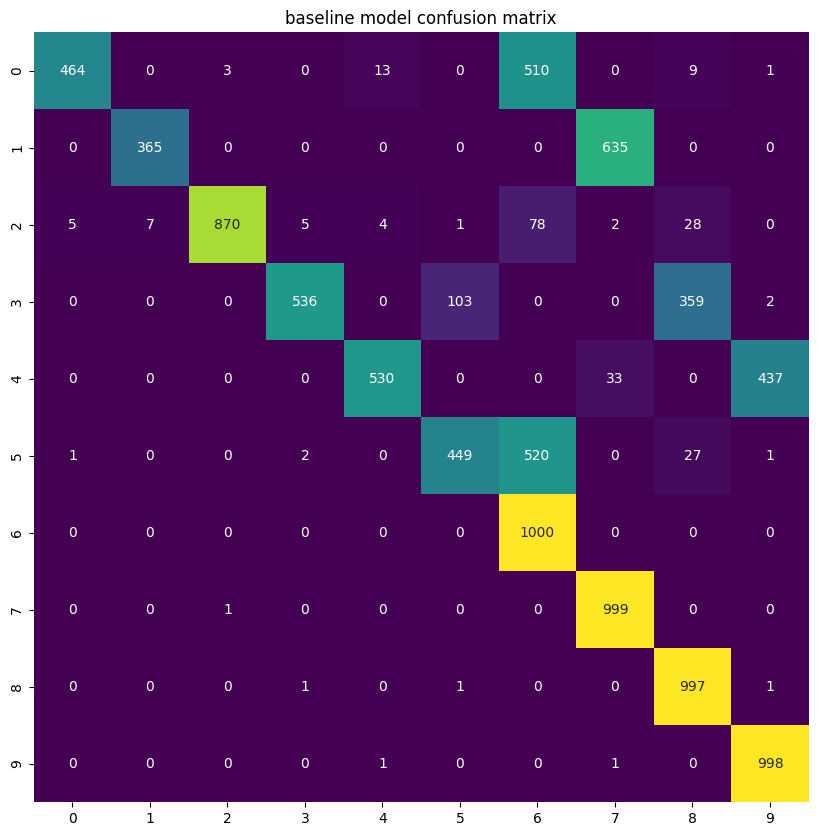

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 10))
# annot=True adds the numbers
# fmt='d' formats them as integers (decimal)
# cmap='viridis' matches the default imshow colors, or try 'Blues'
sns.heatmap(res1["cm10_AB"], annot=True, fmt='d', cmap='viridis', cbar=False)
plt.title(f"EWC model confusion matrix")
plt.savefig(os.path.join(load_labels,"confusion_matrix_A_and_B_V4.png"), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
load_labels = os.path.join(PROJECT_DIR,'Sample_output','task_A_then_B')

res2 = evaluate(load_labels)
print("Accuracy:", res2["accuracy"])
print("Forgetting A->B:", res2["forgetting_A_to_B"])
print("FID:", res2["FID"])

Loading .npz files from /content/drive/Shareddrives/Generative_Models/colab_code/Sample_Data/Sample_output/task_A_then_B...
Successfully loaded 10000 images total.
Accuracy: {'A': 0.8993333333333333, 'B': 0.99775, 'AB': 0.9387}
Forgetting A->B: 0.08133333333319778
FID: {'A': 32.774295604009545, 'B': 17.30727844933368, 'AB': 18.13635840141019}


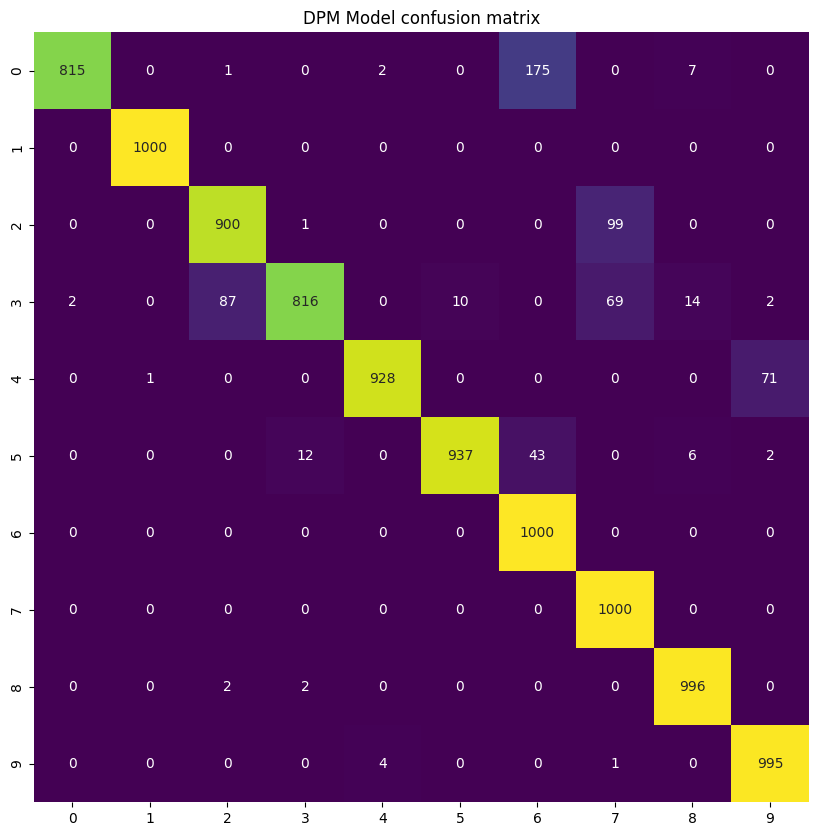

In [ ]:
plt.figure(figsize=(10, 10))
# annot=True adds the numbers
# fmt='d' formats them as integers (decimal)
# cmap='viridis' matches the default imshow colors, or try 'Blues'
sns.heatmap(res2["cm10_AB"], annot=True, fmt='d', cmap='viridis', cbar=False)

plt.title(f"DPM Model confusion matrix")
plt.show()